# 02 — Feature Engineering, Pré-processamento e Seleção de Features

Cria novas features, limpa os dados, define os Pipelines de pré-processamento e analisa a importância de features com 6 métodos.


In [12]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin

import sys
sys.path.insert(0, '..')
from utils.feature_selection import analisar_features


In [13]:
df_churn = pd.read_csv("../data/Telco_customer_churn.csv")
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [14]:
df_churn = df_churn.drop(columns=['Count','CustomerID','Churn Reason'])

df_churn.head()

,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239
1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701
2,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372
3,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003
4,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340


## 4. Feature Engineering

Criação de novas features combinando colunas existentes para capturar padrões mais ricos:

| Feature | Descrição | Churn Rate |
|---------|-----------|------------|
| `high_risk_profile` | Fiber optic + Month-to-month | **54.6%** |
| `isolated_senior` | Idoso sem Partner e sem Dependents | **48.9%** |
| `internet_services_count` | Qtd. de serviços de internet contratados | inversamente proporcional |
| `charge_per_tenure_month` | Monthly Charges / (Tenure Months + 1) | 3.2x maior em churners |

In [15]:
# 1. Combo de maior risco
df_churn['high_risk_profile'] = (
    (df_churn['Internet Service'] == 'Fiber optic') & 
    (df_churn['Contract'] == 'Month-to-month')
).astype(int)

# 2. Perfil vulnerável
df_churn['isolated_senior'] = (
    (df_churn['Senior Citizen'] == 'Yes') & 
    (df_churn['Partner'] == 'No') & 
    (df_churn['Dependents'] == 'No')
).astype(int)

# 3. Engajamento com serviços
servicos = ['Online Security','Online Backup','Device Protection',
            'Tech Support','Streaming TV','Streaming Movies']
df_churn['internet_services_count'] = sum((df_churn[c] == 'Yes').astype(int) for c in servicos)

# 4. Custo relativo ao tempo de permanência
df_churn['cost_per_month'] = df_churn['Monthly Charges'] / (df_churn['Tenure Months'] + 1)

## 5. Pré-processamento e Limpeza

- Conversão de colunas `object` para `float` onde aplicável
- Tratamento de `Total Charges` (armazenado como string com espaços)
- Imputação de valores ausentes com a mediana

In [16]:
# O pré-processamento de tipos (imputação de nulos, conversão de escala e encoding)
# é tratado automaticamente pelos ColumnTransformers dentro dos Pipelines sklearn,
# definidos logo após o split treino/teste.
#
# Abaixo apenas garantimos que 'Total Charges' está como numérico antes do split.
print("Pré-processamento de tipos delegado aos Pipelines (SimpleImputer + OneHotEncoder).")
print(f"Shape atual do dataset: {df_churn.shape}")

Pré-processamento de tipos delegado aos Pipelines (SimpleImputer + OneHotEncoder).
Shape atual do dataset: (7043, 34)


In [17]:
df_churn["Total Charges"] = pd.to_numeric(df_churn["Total Charges"], errors='coerce')

In [18]:
df_churn['Total Charges'] = df_churn['Total Charges'].fillna(df_churn['Total Charges'].median())

In [19]:
df_churn['Total Charges'].describe()

count    7043.000000
mean     2281.916928
std      2265.270398
min        18.800000
25%       402.225000
50%      1397.475000
75%      3786.600000
max      8684.800000
Name: Total Charges, dtype: float64

## 6. Divisão Treino/Teste e Definição dos Pipelines

O encoding das variáveis categóricas e a normalização são feitos **dentro dos Pipelines** (via `OneHotEncoder` e `StandardScaler` no `ColumnTransformer`), eliminando o data leakage que ocorre ao fazer `pd.get_dummies()` antes do split.

In [20]:
from sklearn.model_selection import train_test_split

# ── Remover colunas de data leakage e geográficas desnecessárias ──────────────
colunas_vazar       = ['Churn Score', 'CLTV', 'Churn Label']
colunas_geograficas = ['City', 'Country', 'Lat Long', 'Latitude', 'Longitude', 'Zip Code']
COL_TARGET          = 'Churn Value'

df_churn = df_churn.drop(
    columns=[c for c in colunas_vazar + colunas_geograficas if c in df_churn.columns]
)
print(f"Shape após remoção de leakage e colunas geográficas: {df_churn.shape}")
print(f"States únicos mantidos: {df_churn['State'].nunique()}")

# ── Separar features e target ────────────────────────────────────────────────
X_raw = df_churn.drop(columns=[COL_TARGET])
y     = df_churn[COL_TARGET]

# ── Identificar colunas por tipo (para os ColumnTransformers) ────────────────
num_cols = X_raw.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nFeatures numéricas ({len(num_cols)}): {num_cols}")
print(f"Features categóricas ({len(cat_cols)}): {cat_cols}")

# ── Split treino / teste sobre dados brutos (encoding via Pipeline) ──────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTreino: {X_train_raw.shape} | Teste: {X_test_raw.shape}")
print(f"Distribuição do target (treino): {y_train.value_counts().to_dict()}")

Shape após remoção de leakage e colunas geográficas: (7043, 25)
States únicos mantidos: 1

Features numéricas (7): ['Tenure Months', 'Monthly Charges', 'Total Charges', 'high_risk_profile', 'isolated_senior', 'internet_services_count', 'cost_per_month']
Features categóricas (17): ['State', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Treino: (5634, 24) | Teste: (1409, 24)
Distribuição do target (treino): {0: 4139, 1: 1495}


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# DEFINIÇÃO DOS PREPROCESSORS — base para todos os Pipelines
# ══════════════════════════════════════════════════════════════════════════════

# Bloco numérico sem normalização (tree-based: RF, GB, XGB, LightGBM)
num_passthrough = SKPipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

# Bloco numérico com StandardScaler (modelos sensíveis à escala: LR, KNN, SVM, NN)
num_scaled = SKPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Bloco categórico: imputer + OneHotEncoder (igual para todos os modelos)
# handle_unknown='ignore' → categorias novas no teste não causam erro
cat_pipe = SKPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ColumnTransformer para tree-based (sem escala numérica)
preprocessor_tree = ColumnTransformer([
    ('num', num_passthrough, num_cols),
    ('cat', cat_pipe,        cat_cols),
], remainder='drop')

# ColumnTransformer para modelos sensíveis à escala
preprocessor_scaled = ColumnTransformer([
    ('num', num_scaled, num_cols),
    ('cat', cat_pipe,   cat_cols),
], remainder='drop')

print("Preprocessors definidos:")
print("  preprocessor_tree   → SimpleImputer (sem scaler) + OneHotEncoder")
print("  preprocessor_scaled → SimpleImputer + StandardScaler + OneHotEncoder")

Preprocessors definidos:
  preprocessor_tree   → SimpleImputer (sem scaler) + OneHotEncoder
  preprocessor_scaled → SimpleImputer + StandardScaler + OneHotEncoder


## 8. Seleção de Features

Comparação entre **7 métodos** de seleção com ranking agregado final:

| # | Método | Tipo |
|---|--------|------|
| 1 | SelectKBest (ANOVA F-score) | Filter |
| 2 | SelectKBest (Chi-quadrado) | Filter |
| 3 | Informação Mútua | Filter |
| 4 | Correlação de Pearson | Filter |
| 5 | Random Forest Feature Importance | Embedded |
| 6 | RFE com Regressão Logística | Wrapper |
| 7 | SelectFromModel (RF, limiar=média) | Embedded |

O **ranking agregado** normaliza os scores de todos os métodos para uma seleção robusta das top K features.

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Treino rápido do RF baseline — necessário para extrair o preprocessor
# ajustado no treino e as feature importances para o ranking agregado.
modelo_baseline = SKPipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier',   RandomForestClassifier(n_estimators=100, random_state=42,
                                            n_jobs=-1, class_weight='balanced')),
])
modelo_baseline.fit(X_train_raw, y_train)
print("RF baseline treinado — pronto para análise de features.")

RF baseline treinado — pronto para análise de features.


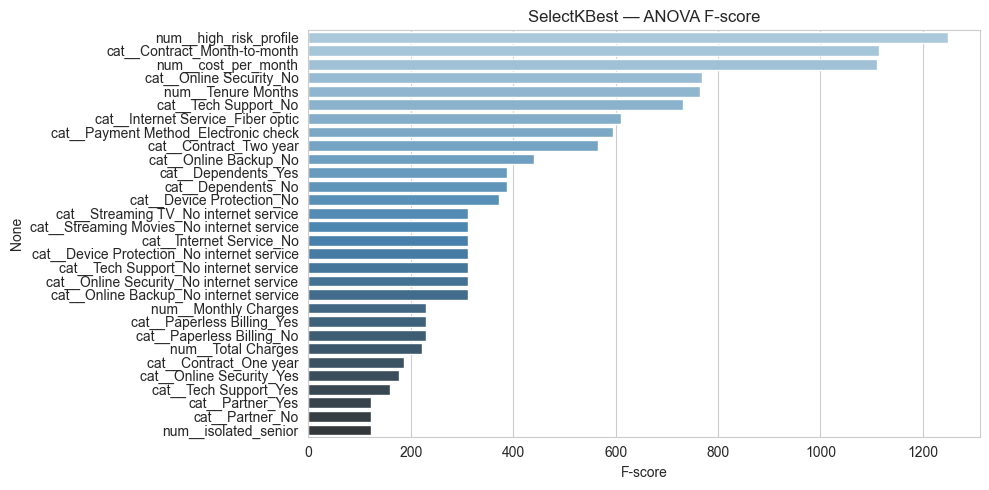

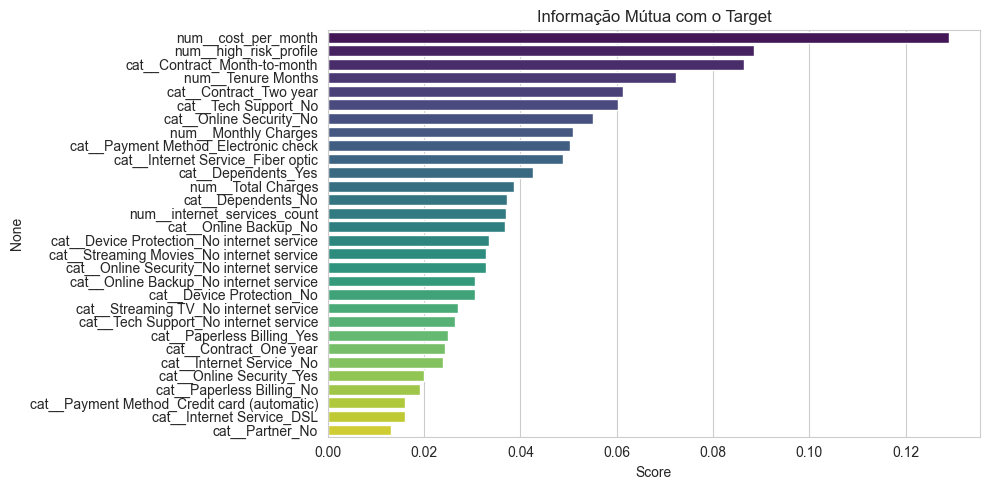

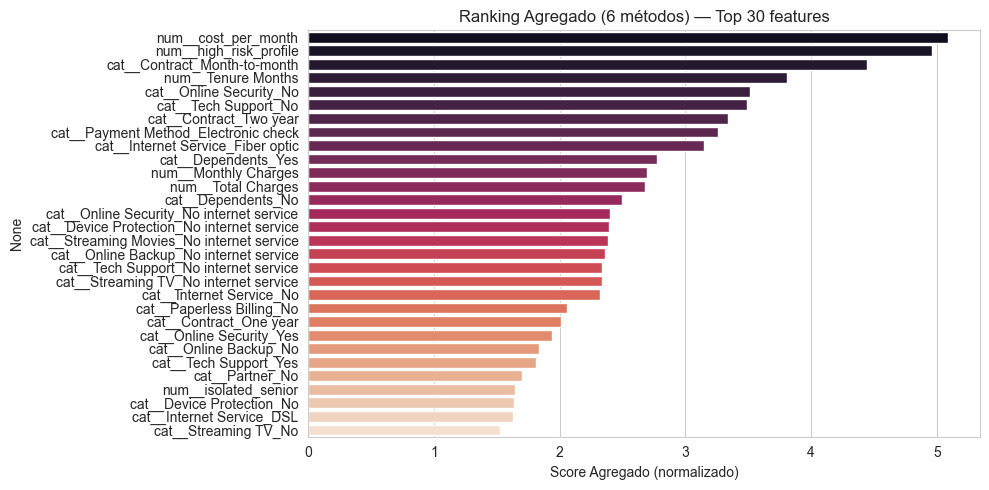


✔ Top 30 features pelo ranking agregado (6 métodos):
['num__cost_per_month', 'num__high_risk_profile', 'cat__Contract_Month-to-month', 'num__Tenure Months', 'cat__Online Security_No', 'cat__Tech Support_No', 'cat__Contract_Two year', 'cat__Payment Method_Electronic check', 'cat__Internet Service_Fiber optic', 'cat__Dependents_Yes', 'num__Monthly Charges', 'num__Total Charges', 'cat__Dependents_No', 'cat__Online Security_No internet service', 'cat__Device Protection_No internet service', 'cat__Streaming Movies_No internet service', 'cat__Online Backup_No internet service', 'cat__Tech Support_No internet service', 'cat__Streaming TV_No internet service', 'cat__Internet Service_No', 'cat__Paperless Billing_No', 'cat__Contract_One year', 'cat__Online Security_Yes', 'cat__Online Backup_No', 'cat__Tech Support_Yes', 'cat__Partner_No', 'num__isolated_senior', 'cat__Device Protection_No', 'cat__Internet Service_DSL', 'cat__Streaming TV_No']

SelectKBest(f_classif, k=30) nos Pipelines captura 

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# ANÁLISE DE FEATURES — via src/feature_selection.analisar_features
# Compara 6 métodos e retorna ranking agregado. Os resultados confirmam
# o uso de SelectKBest(f_classif, k=30) nos Pipelines da Seção 9.
# ══════════════════════════════════════════════════════════════════════════════

# Obter features encodadas usando o preprocessor do baseline (já ajustado no treino)
_prep          = modelo_baseline.named_steps['preprocessor']
X_tr_enc       = pd.DataFrame(_prep.transform(X_train_raw), columns=_prep.get_feature_names_out())

# Feature importances do RF baseline para incluir no ranking (método 6)
rf_imp = pd.Series(
    modelo_baseline.named_steps['classifier'].feature_importances_,
    index=_prep.get_feature_names_out(),
)

top_k, ranking_agregado = analisar_features(
    X_tr_enc, y_train,
    k=30,
    rf_importances=rf_imp,
    plot=True,
)

print(f"\nSelectKBest(f_classif, k=30) nos Pipelines captura automaticamente as melhores features.")